# 개인정보보호법 RAG 그래프

**주제**: 개인정보보호법 (법률 제19234호, 2023. 9. 15. 시행)  
**문서 출처**: [casenote.kr](https://casenote.kr/법령/개인정보_보호법) (국가법령정보센터 기반)  
**패턴**: Self-RAG (04_tax_graph.ipynb와 동일 구조)

## 그래프 흐름
```
START → retrieve → check_doc_relevance
                        │              │
                     generate       rewrite → retrieve (루프)
                        │
                   check_hallucination
                        │                │
                 not hallucinated    generate (재생성 루프)
                        │
                       END
```

## Step 1. 환경 변수 로드

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Step 2. 문서 로드 및 청킹

`data/privacy_law.txt` 파일을 로드하여 청킹합니다.  
세법 예제와 달리 txt 파일을 사용하므로 `TextLoader`를 사용합니다.

In [2]:
from langchain_community.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

# 문서 로드
loader = TextLoader('./data/privacy_law.txt', encoding='utf-8')
documents = loader.load()

print(f'로드된 문서 수: {len(documents)}')
print(f'전체 문서 길이: {len(documents[0].page_content)} 자')

로드된 문서 수: 1
전체 문서 길이: 12462 자


In [3]:
# 조문 단위로 청킹 (chunk_size=800, overlap=100)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=['\n\n제', '\n\n①', '\n\n②', '\n\n③', '\n\n']
)

chunks = text_splitter.split_documents(documents)
print(f'청킹 결과: {len(chunks)}개 청크')
print('\n--- 첫 번째 청크 ---')
print(chunks[0].page_content[:300])

청킹 결과: 24개 청크

--- 첫 번째 청크 ---
개인정보 보호법
[시행 2023. 9. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]
출처: 국가법령정보센터 (casenote.kr 참조)

제1장 총칙

제1조(목적)
이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인의 존엄과 가치를 구현함을 목적으로 한다.


## Step 3. 임베딩 설정 및 Pinecone 벡터스토어 구축

세법 예제와 동일하게 `text-embedding-3-large` 모델을 사용합니다.  
Pinecone 인덱스명: `privacy-index`

In [4]:
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(model='text-embedding-3-large')

c:\workspace\langgraph_work\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
import os
import time

index_name = 'privacy-index'
pinecone_api_key = os.getenv('PINECONE_API_KEY')
pc = Pinecone(api_key=pinecone_api_key)

# 인덱스 없으면 생성 (text-embedding-3-large = 3072 차원)
existing_indexes = [idx['name'] for idx in pc.list_indexes()]

if index_name not in existing_indexes:
    print(f'인덱스 [{index_name}] 생성 중...')
    pc.create_index(
        name=index_name,
        dimension=3072,
        metric='cosine',
        spec=ServerlessSpec(cloud='aws', region='us-east-1')
    )
    # 인덱스 준비 대기
    while not pc.describe_index(index_name).status['ready']:
        time.sleep(1)
    print('인덱스 생성 완료!')
    
    # 문서 임베딩 및 저장
    print('문서 임베딩 및 Pinecone 저장 중...')
    vectorstore = PineconeVectorStore.from_documents(
        documents=chunks,
        embedding=embedding,
        index_name=index_name
    )
    print(f'{len(chunks)}개 청크 저장 완료!')
else:
    print(f'기존 인덱스 [{index_name}] 로드')
    vectorstore = PineconeVectorStore(
        index_name=index_name,
        embedding=embedding
    )

인덱스 [privacy-index] 생성 중...
인덱스 생성 완료!
문서 임베딩 및 Pinecone 저장 중...
24개 청크 저장 완료!


In [6]:
# 검색 테스트
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})

test_query = '개인정보를 제3자에게 제공할 때 필요한 절차는?'
docs = retriever.invoke(test_query)

print(f'검색된 문서 수: {len(docs)}')
for i, doc in enumerate(docs):
    print(f'\n--- 문서 {i+1} ---')
    print(doc.page_content[:200])

검색된 문서 수: 3

--- 문서 1 ---
제17조(개인정보의 제공)
① 개인정보처리자는 다음 각 호의 어느 하나에 해당되는 경우에는 정보주체의 개인정보를 제3자에게 제공(공유를 포함한다. 이하 같다)할 수 있다.
1. 정보주체의 동의를 받은 경우
2. 제15조제1항제2호, 제3호 및 제5호부터 제7호까지에 따라 개인정보를 수집한 목적 범위에서 개인정보를 제공하는 경우

② 개인정보처리자는 제1항제

--- 문서 2 ---
② 제1항에도 불구하고 개인정보처리자는 다음 각 호의 어느 하나에 해당하는 경우에는 정보주체 또는 제3자의 이익을 부당하게 침해할 우려가 있을 때를 제외하고는 개인정보를 목적 외의 용도로 이용하거나 이를 제3자에게 제공할 수 있다.
1. 정보주체로부터 별도의 동의를 받은 경우
2. 다른 법률에 특별한 규정이 있는 경우
3. 정보주체 또는 그 법정대리인이 의

--- 문서 3 ---
③ 개인정보처리자는 제2항제1호에 따른 동의를 받을 때에는 다음 각 호의 사항을 정보주체에게 알려야 한다.
1. 개인정보를 제공받는 자
2. 개인정보의 이용 목적(제공 시에는 제공받는 자의 이용 목적을 말한다)
3. 이용 또는 제공하는 개인정보의 항목
4. 개인정보의 보유 및 이용 기간(제공 시에는 제공받는 자의 보유 및 이용 기간을 말한다)
5. 동의를 


## Step 4. LLM 및 AgentState 설정

In [7]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

In [8]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

## Step 5. 노드 정의

### 5-1. retrieve 노드

In [9]:
def retrieve(state: AgentState) -> AgentState:
    """사용자 질문에 기반하여 개인정보보호법 문서를 검색합니다."""
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

### 5-2. generate 노드

In [10]:
from langchain import hub

generate_prompt = hub.pull('rlm/rag-prompt')

def generate(state: AgentState) -> AgentState:
    """검색된 개인정보보호법 문서를 기반으로 답변을 생성합니다."""
    context = state['context']
    query = state['query']

    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})

    return {'answer': response}

### 5-3. rewrite 노드

개인정보보호법 전용 사전을 사용하여 질문을 법령 용어로 재작성합니다.

In [11]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# 개인정보보호법 전용 용어 사전
dictionary = [
    "사람 또는 회사 → 개인정보처리자",
    "사용자, 고객, 이용자 → 정보주체",
    "개인정보 삭제 요청 → 개인정보의 정정·삭제 요구",
    "개인정보 열람 요청 → 개인정보의 열람",
    "정보 유출 → 개인정보 유출·도난·분실",
    "보안 담당자 → 개인정보 보호책임자",
    "민감한 정보 → 민감정보",
    "주민번호, 여권번호 → 고유식별정보",
    "외부 업체 활용 → 업무위탁",
    "개인정보 공유 → 제3자 제공",
]

rewrite_prompt = ChatPromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 개인정보보호법 사전을 참고해서 사용자의 질문을 법령 용어에 맞게 변경해 주세요.
만약 변경할 필요가 없다고 판단된다면, 사용자의 질문을 변경하지 않아도 됩니다.
질문 내용 중에 '*' 표시를 제거합니다.

사전: {dictionary}

질문: {{question}}
""")

def rewrite(state: AgentState) -> AgentState:
    """개인정보보호법 사전을 고려하여 사용자 질문을 재작성합니다."""
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'question': query})
    print(f'[rewrite] {query} → {response}')
    return {'query': response}

## Step 6. 조건부 엣지 정의

### 6-1. check_doc_relevance (문서 관련성 판단)

In [12]:
from langchain import hub
from typing import Literal

doc_relevance_prompt = hub.pull('langchain-ai/rag-document-relevance')

def check_doc_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    """검색된 문서가 질문과 관련 있는지 판단합니다."""
    context = state['context']
    query = state['query']

    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})

    score = response.get('Score', 0)
    print(f'[check_doc_relevance] Score: {score}')

    if score == 1:
        return 'generate'
    return 'rewrite'

### 6-2. check_hallucination (환각 여부 판단)

In [13]:
from langchain_core.prompts import PromptTemplate

hallucination_prompt = PromptTemplate.from_template("""
You are a teacher evaluating whether a student's answer is grounded in the provided documents.
The documents are excerpts from the Korean Personal Information Protection Act (개인정보보호법).

Given the documents and the student's answer:
- If the answer is based on the documents, respond with "not hallucinated"
- If the answer contains information not found in the documents, respond with "hallucinated"

documents: {documents}
student_answer: {student_answer}
""")

def check_hallucination(state: AgentState) -> Literal['hallucinated', 'not hallucinated']:
    """생성된 답변이 문서에 근거하는지 확인합니다."""
    answer = state['answer']
    context = state['context']

    hallucination_chain = hallucination_prompt | llm | StrOutputParser()
    response = hallucination_chain.invoke({
        'student_answer': answer,
        'documents': context
    })

    print(f'[check_hallucination] {response}')
    return response.strip()

## Step 7. LangGraph 그래프 구성

In [14]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

# 노드 등록
builder.add_node('retrieve', retrieve)
builder.add_node('generate', generate)
builder.add_node('rewrite', rewrite)

# 엣지 연결
builder.add_edge(START, 'retrieve')
builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'generate': 'generate',
        'rewrite': 'rewrite'
    }
)
builder.add_edge('rewrite', 'retrieve')
builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
        'not hallucinated': END,
        'hallucinated': 'generate'
    }
)

graph = builder.compile()
print('그래프 컴파일 완료!')

그래프 컴파일 완료!


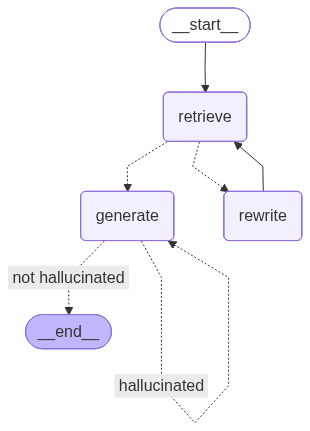

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Step 8. 테스트

개인정보보호법과 관련된 실제 질문들로 그래프를 테스트합니다.

In [16]:
# 테스트 1: 기본 질문 (직접 검색 가능)
query = '개인정보를 제3자에게 제공할 때 정보주체에게 어떤 사항을 알려야 하나요?'

initial_state = {'query': query}
result = graph.invoke(initial_state)

print('\n=== 최종 답변 ===')
print(result['answer'].content)

[check_doc_relevance] Score: 1
[check_hallucination] not hallucinated

=== 최종 답변 ===
개인정보를 제3자에게 제공할 때 정보주체에게 알려야 할 사항은 다음과 같습니다: 개인정보를 제공받는 자, 제공받는 자의 이용 목적, 제공하는 개인정보의 항목, 보유 및 이용 기간, 동의를 거부할 권리와 그에 따른 불이익 내용입니다. 이러한 정보는 정보주체의 동의를 받을 때 반드시 제공해야 합니다.


In [17]:
# 테스트 2: 용어 재작성이 필요한 질문
query = '고객 정보가 유출됐을 때 회사는 무엇을 해야 하나요?'

initial_state = {'query': query}
result = graph.invoke(initial_state)

print('\n=== 최종 답변 ===')
print(result['answer'].content)

[check_doc_relevance] Score: 1
[check_hallucination] not hallucinated

=== 최종 답변 ===
회사는 고객 정보가 유출되었을 때, 즉시 해당 정보주체에게 유출된 개인정보의 항목, 발생 시점과 경위, 피해 최소화를 위한 방법 등을 알려야 합니다. 또한, 피해를 최소화하기 위한 방안을 마련하고, 필요 시 관련 기관에 신고해야 합니다. 이러한 조치는 법적으로 요구되는 절차입니다.


In [18]:
# 테스트 3: 민감정보 관련
query = '건강 정보나 노동조합 가입 여부 같은 민감한 정보는 어떻게 처리해야 하나요?'

initial_state = {'query': query}
result = graph.invoke(initial_state)

print('\n=== 최종 답변 ===')
print(result['answer'].content)

[check_doc_relevance] Score: 1
[check_hallucination] not hallucinated

=== 최종 답변 ===
민감한 정보는 원칙적으로 처리할 수 없지만, 정보주체의 동의를 받거나 법령에서 요구하는 경우에는 예외적으로 처리할 수 있습니다. 이 경우, 민감정보의 안전성을 확보하기 위한 조치를 취해야 합니다. 또한, 민감정보가 공개될 가능성이 있을 경우, 정보주체에게 이를 알리고 비공개 방법을 선택할 수 있도록 해야 합니다.


In [19]:
# 테스트 4: 정보주체 권리
query = '이용자가 자신의 개인정보 삭제를 요청하면 어떻게 처리해야 하나요?'

initial_state = {'query': query}
result = graph.invoke(initial_state)

print('\n=== 최종 답변 ===')
print(result['answer'].content)

[check_doc_relevance] Score: 1
[check_hallucination] not hallucinated

=== 최종 답변 ===
이용자가 자신의 개인정보 삭제를 요청하면, 개인정보처리자는 지체 없이 해당 개인정보를 조사하고 요구에 따라 정정 또는 삭제 등의 필요한 조치를 취해야 합니다. 삭제 시에는 복구 또는 재생되지 않도록 조치해야 하며, 요청이 거절될 경우 그 사유를 즉시 알려야 합니다.


In [20]:
# 테스트 5: 손해배상
query = '개인정보처리자가 개인정보를 유출해서 피해가 발생하면 손해배상은 얼마까지 가능한가요?'

initial_state = {'query': query}
result = graph.invoke(initial_state)

print('\n=== 최종 답변 ===')
print(result['answer'].content)

[check_doc_relevance] Score: 1
[check_hallucination] not hallucinated

=== 최종 답변 ===
개인정보처리자가 고의 또는 중대한 과실로 인해 개인정보 유출로 피해가 발생한 경우, 법원은 손해배상액을 손해액의 5배를 넘지 않는 범위에서 정할 수 있습니다. 개인정보처리자가 고의 또는 중대한 과실이 없음을 증명하면 책임을 면할 수 있습니다.
